importing libraries # 

In [ ]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array,load_img
import numpy as np

checking for corrupted imgs # 

In [92]:
file_path = "/kaggle/input/preproccing-dataset"
corrupted_images = []
extentions = []

sample_images = []

num_samples_per_class = 3  # عدد الصور لكل class

for class_name in os.listdir(file_path):
    class_path = os.path.join(file_path, class_name)
    if not os.path.isdir(class_path):
        continue

    class_imgs = []
    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        root, extention = os.path.splitext(img_path)
        if extention not in extentions:
            extentions.append(extention)
        
        try:
            if os.path.isfile(img_path) and img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                img = Image.open(img_path)
                img.verify()
                class_imgs.append(img_path)
        except Exception as es:
            corrupted_images.append(img_path)
            print(f"corrupted image path: {img_path}")

    # اختيار أكثر من صورة لكل class
    if class_imgs:
        sample_images.extend(random.sample(class_imgs, min(num_samples_per_class, len(class_imgs))))

print(f"Number of corrupted images: {len(corrupted_images)}")
print(f"Extensions found: {extentions}")





Number of corrupted images: 0
Extensions found: ['.jpg', '.jpeg']


showing 3 iamges from each class

In [ ]:
# عرض الصور المختارة
num_cols = num_samples_per_class
num_rows = (len(sample_images) + num_cols - 1) // num_cols
plt.figure(figsize=(5*num_cols, 5*num_rows))
for i, img_path in enumerate(sample_images):
    img = Image.open(img_path)
    plt.subplot(num_rows, num_cols, i+1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(os.path.basename(img_path))

plt.tight_layout()
plt.show()


Data Augmentation # 

In [62]:
#generating image data generator from keras to apply augmentation on images 
data_generator = ImageDataGenerator(
    rotation_range=10, # rotation by + or - 10 degree
    width_shift_range=0.1,#shifting width of image by 10%
    height_shift_range=0.1,#shifting height by 10%
    zoom_range=0.1,#zoom in or out by 10
    horizontal_flip=False,# preventing pliping for the misleading 
    fill_mode="nearest"
)

In [64]:
train_generator = data_generator.flow_from_directory(
    '/kaggle/input/preproccing-dataset/', 
    target_size=(128, 128),                
    batch_size=32,                        
    class_mode='categorical'               
)


Found 5800 images belonging to 29 classes.


showing randomly images after applying augmentation# 

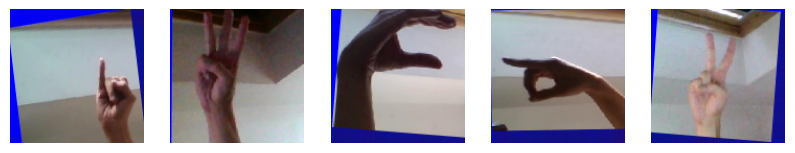

In [65]:
x_batch, y_batch = next(train_generator)  
plt.figure(figsize=(10, 5))              
for i in range(5):                       
    plt.subplot(1, 5, i+1)               
    plt.imshow(x_batch[i].astype('uint8')) 
    plt.axis('off')                        
plt.show()                                 


showing an original image and the augmented versions of it # 

In [78]:
import numpy as np
M_image="/kaggle/input/preproccing-dataset/M/113.jpg"
img = load_img(M_image, target_size=(128, 128))  
x = img_to_array(img) 
x = np.expand_dims(x, axis=0)  # خليها batch size 1
augmented_img= data_generator.flow(x,batch_size=1)


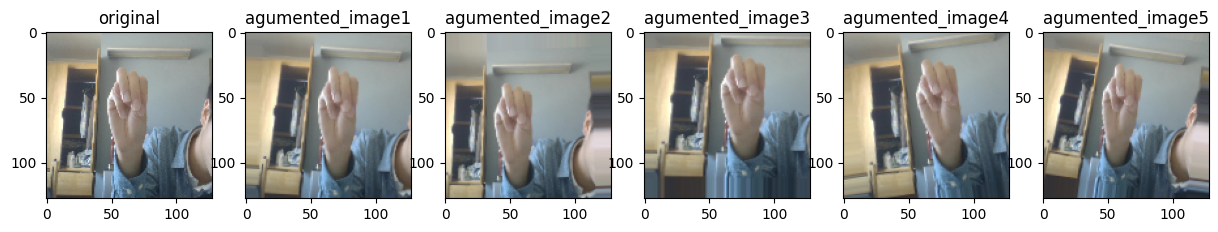

In [83]:
plt.figure(figsize=(15,8))
#original image
plt.subplot(1,6,1)
plt.imshow(x[0].astype("uint8"))
plt.title("original")

#augmented images
for i in range(5):
    batch=next(augmented_img)
    img_aug=batch[0]
    plt.subplot(1,6,i+2)
    plt.imshow(img_aug.astype('uint8'))
    plt.title(f"agumented_image{i+1}")


